# Car Price Analysis Project

## 1.Importing Libraries 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split

## 2.Reading Data Set 

In [6]:
df = pd.read_csv("../data/car_price.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (72435, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


## 3.Exploratory Data Analysis 'EDA'

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 7.1 MB


In [8]:
df.columns = ['Model', 'Year', 'Price','Transmission','Mileage','Fuel Type','Tax','MPG','Engine Size','Brand']
df.columns.tolist()

['Model',
 'Year',
 'Price',
 'Transmission',
 'Mileage',
 'Fuel Type',
 'Tax',
 'MPG',
 'Engine Size',
 'Brand']

In [9]:
df.isnull().sum()

Model           3621
Year            3622
Price           3621
Transmission    3623
Mileage         3622
Fuel Type       3622
Tax             3621
MPG             3621
Engine Size     3622
Brand           3621
dtype: int64

In [10]:
df['Brand'].value_counts()

Brand
Ford       17045
vw         14393
BMW        10269
audi       10137
toyota      6417
skoda       5947
Hyundai     4606
Name: count, dtype: int64

In [11]:
df['Fuel Type'].value_counts()

Fuel Type
Petrol      38390
Diesel      27446
Hybrid       2747
Other         225
Electric        5
Name: count, dtype: int64

In [12]:
df['Transmission'].value_counts()

Transmission
Manual       40839
Semi-Auto    14611
Automatic    13358
Other            4
Name: count, dtype: int64

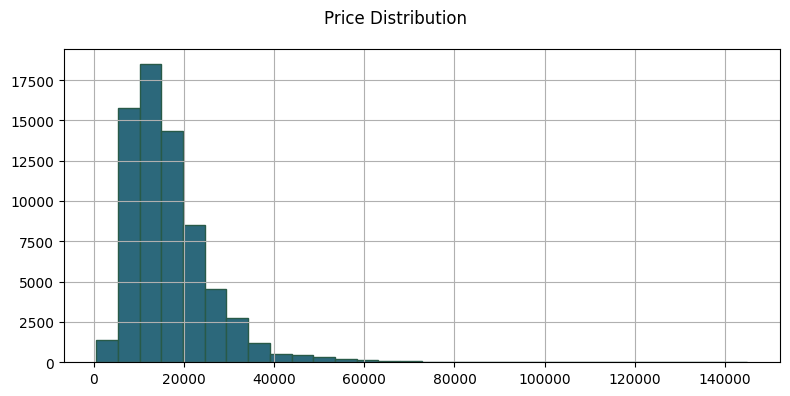

In [13]:
df['Price'].hist(figsize=(8, 4), bins=30, edgecolor='#285A48', color='#2C687B')
plt.suptitle('Price Distribution')
plt.tight_layout()
plt.show()

In [14]:
df.describe()

,Year,Price,Mileage,Tax,MPG,Engine Size
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


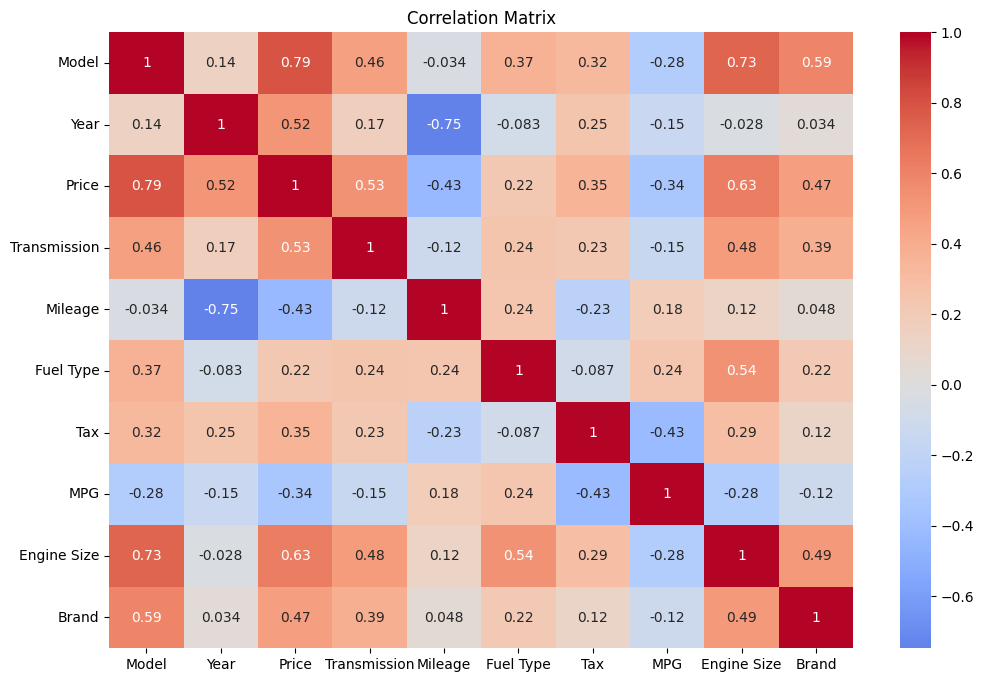

In [15]:
X_encoded = X_train.copy()
y_corr = y_train.copy()
df_corr = pd.concat([X_encoded, y_corr], axis=1)
cat_cols = X_encoded.select_dtypes(include=['object']).columns
for col in cat_cols:
    means = df.groupby(col)['Price'].mean()
    df_corr[col] = df_corr[col].map(means)
corr_matrix = df_corr.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
print(corr_with_price)

## 4.Data Preprocessing

### 1.Handling Missing Values

In [16]:
# We only drop rows with missing value in the target column (the price)***
df = df.dropna(subset=['Price'])

In [17]:
# *Splitting the data before cleaning to prevent data leakage

X = df.drop('Price',axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

## Missing Values for Numerical Data

In [18]:
# Handling missing values for numeric features Using the median (Robust against outliers), since only around 5% of each column is missing, we are not going to drop them

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy="median")
X_train[numeric_cols] = numeric_imputer.fit_transform(X_train[numeric_cols])

# Fitting only on Training data and trasforiming both to prevent data leakage

X_test[numeric_cols] = numeric_imputer.transform(X_test[numeric_cols])

## Missing Values for Categorical Data
using multi-level conditional imputation is better than a generic most-frequent fill to preserve the logical relationships between variables and maintain the statistical distribution of the dataset. 

In [19]:
impute_map = {
    'Model':        'Brand',
    'Brand':         'Model',
    'Fuel Type':     'Model',
    'Transmission': 'Model'
}

for target, ref in impute_map.items():
    global_mode = X_train[target].mode()[0]
    
    train_rules = X_train.groupby(ref)[target].agg(
        lambda x: x.mode()[0] if not x.mode().empty else global_mode
    )
    
    X_train[target] = X_train[target].fillna(X_train[ref].map(train_rules))
    
    X_test[target] = X_test[target].fillna(X_test[ref].map(train_rules))
    X_test[target] = X_test[target].fillna(global_mode) 

In [21]:
# Checking for any missing values
X_train.isnull().sum().sum() + X_test.isnull().sum().sum()

np.int64(0)

In [22]:
y_train.isnull().sum().sum() + y_test.isnull().sum().sum()

np.int64(0)

# Outliers Detection and Handling Using the IQR Method

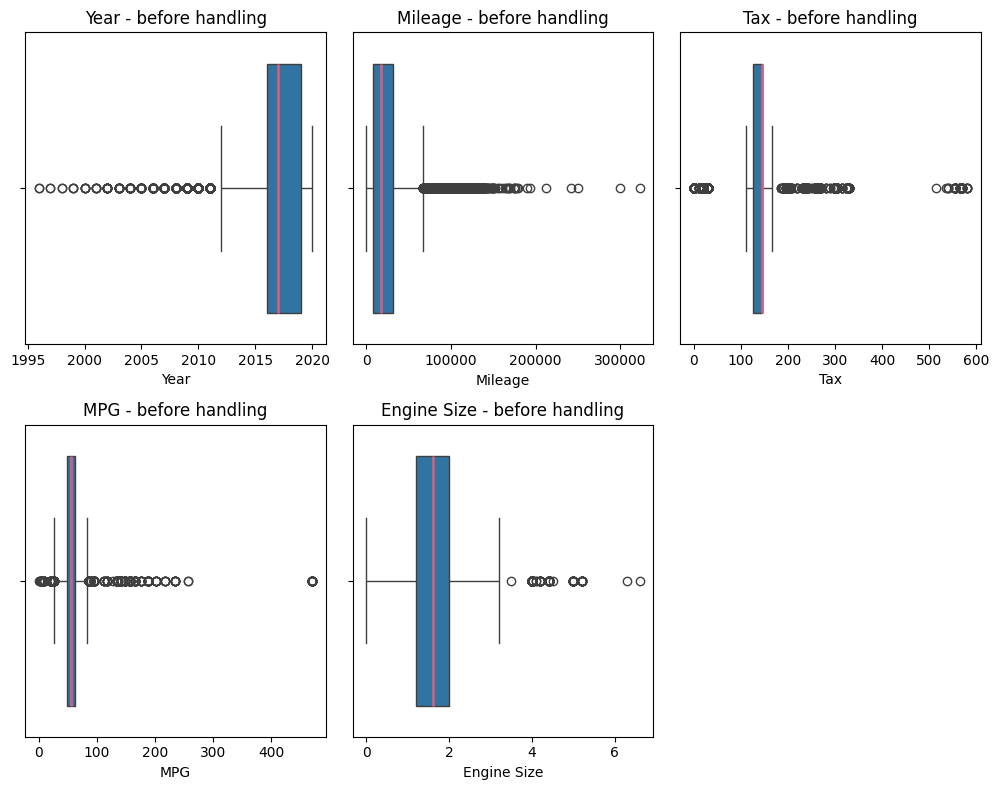

In [23]:
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns
#Detect Outliers using boxplot in featuers
cols = 3
rows = (len(numeric_features) + cols - 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(numeric_features):
    sns.boxplot(
        x=X_train[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2} 
    )
    axes[i].set_title(f'{col} - before handling')

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

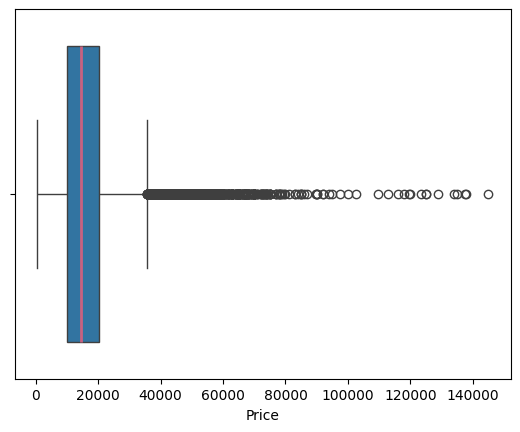

In [25]:
#Detect Outliers using boxplot in Price
sns.boxplot(
        x=y_train,
        medianprops={"color": "#CA6180", "linewidth": 2});

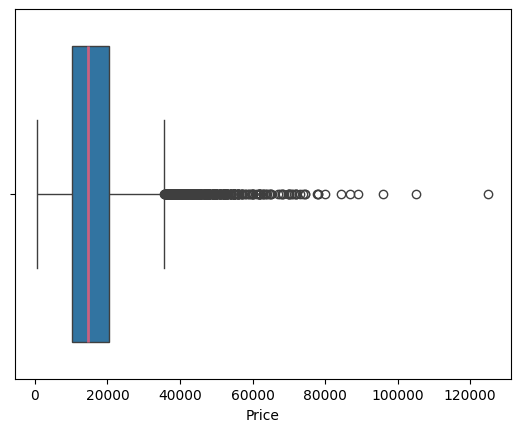

In [26]:
#Detect Outliers using boxplot in Price
sns.boxplot(
        x=y_test,
        medianprops={"color": "#CA6180", "linewidth": 2});

In [27]:
# Clipping Values out of IQR Bounds
for col in numeric_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

In [28]:
# Using data from the training set to prevent data leakage
Q1_y = y_train.quantile(0.25)
Q3_y = y_train.quantile(0.75)
IQR_y = Q3_y - Q1_y

lower_y = Q1_y - 1.5 * IQR_y
upper_y = Q3_y + 1.5 * IQR_y

y_train = y_train.clip(lower=lower_y, upper=upper_y)
y_test = y_test.clip(lower=lower_y, upper=upper_y)

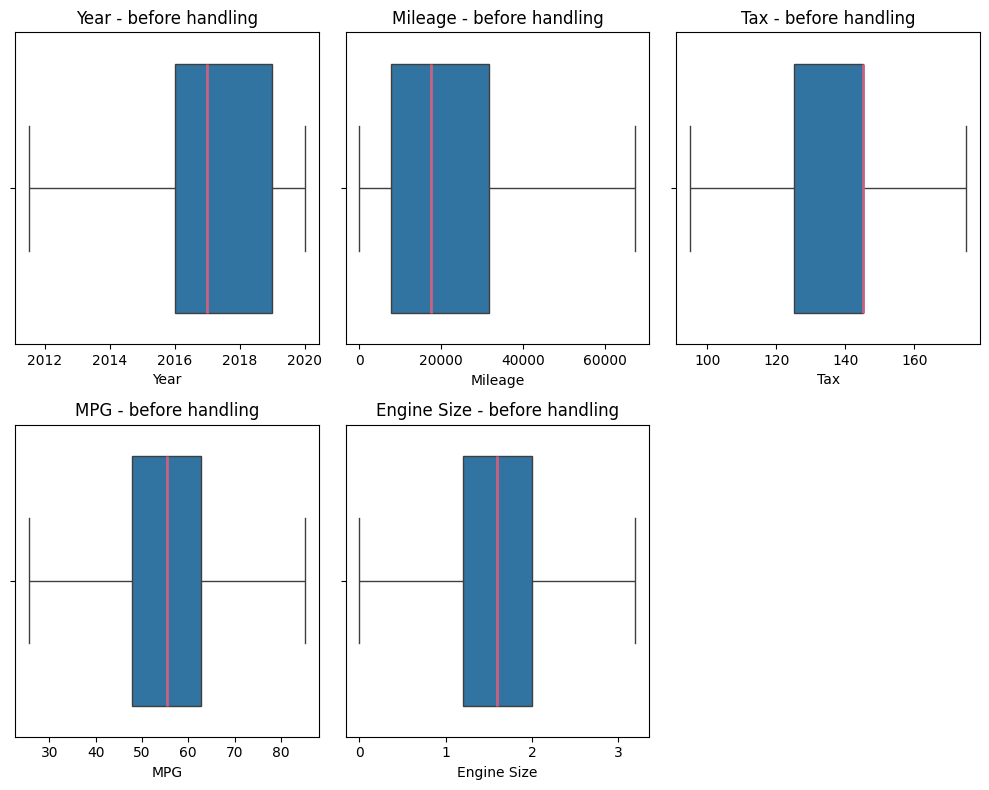

In [29]:
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns
#Detect Outliers using boxplot in featuers
cols = 3
rows = (len(numeric_features) + cols - 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
axes = axes.flatten()


for i, col in enumerate(numeric_features):
    sns.boxplot(
        x=X_train[col],
        ax=axes[i],
        medianprops={"color": "#CA6180", "linewidth": 2} 
    )
    axes[i].set_title(f'{col} - before handling')

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

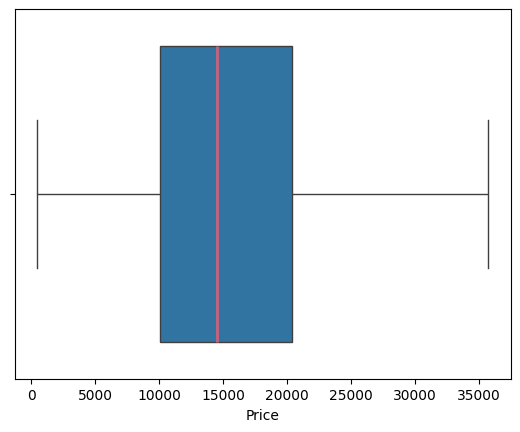

In [30]:
#Detect Outliers using boxplot in Price
sns.boxplot(
        x=y_train,
        medianprops={"color": "#CA6180", "linewidth": 2});

# Scaling Numerical Features Using the StandardScaler

In [31]:
numeric_cols_to_scale = ['Year', 'Mileage', 'Tax', 'MPG', 'Engine Size']

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test_num_scaled  = scaler.transform(X_test[numeric_cols_to_scale])

X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=numeric_cols_to_scale, index=X_train.index)
X_test_num_scaled  = pd.DataFrame(X_test_num_scaled,  columns=numeric_cols_to_scale, index=X_test.index)



In [32]:
X_train_num_scaled.describe()

,Year,Mileage,Tax,MPG,Engine Size
count,5.505100e+04,5.505100e+04,5.505100e+04,5.505100e+04,5.505100e+04
mean,-1.140642e-14,-4.181865e-17,5.183447e-16,4.357400e-16,4.295446e-16
std,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00
min,-3.050903e+00,-1.222883e+00,-1.653160e+00,-2.641789e+00,-3.097190e+00
25%,-6.082096e-01,-7.971567e-01,-3.837725e-01,-6.508595e-01,-8.151725e-01
50%,-6.538875e-02,-2.514024e-01,4.624862e-01,1.723752e-02,-5.450005e-02
75%,1.020253e+00,5.271967e-01,4.624862e-01,6.764266e-01,7.061724e-01
max,1.563074e+00,2.513727e+00,1.731874e+00,2.667356e+00,2.988190e+00


# Encoding
Using One-Hot Encoding because there is no ordinal relationship between columns

In [33]:
cat_cols = ['Model', 'Transmission', 'Fuel Type', 'Brand']

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_enc = enc.fit_transform(X_train[cat_cols])
X_test_enc = enc.transform(X_test[cat_cols])

encoded_cols = enc.get_feature_names_out(cat_cols)

X_train_ohe = pd.DataFrame(X_train_enc, columns=encoded_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_enc, columns=encoded_cols, index=X_test.index)

In [34]:
X_train_final = X_train_num_scaled.join(X_train_ohe)
X_test_final  = X_test_num_scaled.join(X_test_ohe)

In [35]:
# Save the 4 datasets
X_train_final.to_csv('X_train_cleaned.csv', index=False)
X_test_final.to_csv('X_test_cleaned.csv', index=False)
y_train.to_csv('y_train_cleaned.csv', index=False)
y_test.to_csv('y_test_cleaned.csv', index=False)